In [1]:
import os
from pathlib import Path
import re
import warnings
from itertools import combinations

import pandas as pd
import numpy as np
from scipy.stats import wilcoxon, rankdata

import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import seaborn as sns
from IPython.display import display

In [2]:
BASE_DIR = Path("results")
OUTPUT_DIR = BASE_DIR / "evaluation"
TABLE_DIR = OUTPUT_DIR / "tables"
PLOT_DIR = OUTPUT_DIR / "plots"
BASE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

METHOD_CONFIG = {
    "random_mask": {
        "directory": BASE_DIR / "random_baseline_results",
        "files": {
            "spans": "random_best_config_test_per_argument.csv",
            "summary": "random_best_config_split_summary.csv",
            "confusion_summary": (
                "random_best_config_confusion_summary.csv"
            ),
        },
    },
    "llm": {
        "directory": BASE_DIR / "llm_reference",
        "files": {
            "spans": "llm_test_tp_spans_argument_level.csv",
            "summary": "llm_span_mask_eval_summary.csv"
        }
    },
    "tfidf": {
        "directory": (
            BASE_DIR
            / "tfidf_baseline_results"
            / "final_test_all_window3_topk5"
        ),
        "prefix": "tfidf_final_test_all_window3_topk5",
    },
    "attention": {
        "directory": (
            BASE_DIR
            / "attention_results"
            / "attention_results_word_boundary"
        ),
        "prefix": "attention_final_all_splits_last_cls_q0.6_window3",
    },
    "ig": {
        "directory": BASE_DIR / "ig_results" / "ig_results_final",
        "prefix": "ig_final_all_splits_q0.5_window1",
    },
    "shap_best": {
        "directory": BASE_DIR / "shap_results" / "shap_results_final",
        "prefix": "shap_final_test_q0.5_window0",
    },
    # "shap_greedy": {
    #     "directory": (
    #         BASE_DIR
    #         / "shap_results"
    #         / "shap_results_diff_config"
    #     ),
    #     "prefix": "shap_final_all_splits_q0.5_window3",
    # },
    "mil_best": {
        "directory": (
            BASE_DIR
            / "mil_results"
            / "mil_span_run_singles"
            / "mil_results_final"
        ),
        "prefix": (
            "mil_final_all_splits_"
            "pool=topk_noisy_or__topk=5__"
            "spans=8__stride=4__freeze=True"
        ),
    },
    # "mil_greedy": {
    #     "directory": (
    #         BASE_DIR
    #         / "mil_results"
    #         / "mil_span_run_20260727_114312"
    #     ),
    #     "prefix": (
    #         "mil_final_all_splits_"
    #         "pool=max__topk=1__"
    #         "spans=5-10-15__stride=2__freeze=True"
    #     ),
    # },
}

In [3]:
def build_method_paths(config: dict) -> dict[str, Path]:
    """
    Construct the three result paths for one method.

    A method can either define explicit filenames via ``files`` or provide
    a common filename prefix.
    """
    directory = config["directory"]

    if "files" in config:
        return {
            file_type: directory / filename
            for file_type, filename in config["files"].items()
        }

    prefix = config["prefix"]

    return {
        "spans": directory / f"{prefix}_argument_level.csv",
        "summary": directory / f"{prefix}_overall_summary.csv",
        "confusion_summary": (
            directory / f"{prefix}_confusion_summary.csv"
        ),
    }

def load_method_results(
    method_paths: dict[str, dict[str, Path]],
    *,
    add_method_column: bool = True,
) -> dict[str, dict[str, pd.DataFrame]]:
    """
    Load all result CSV files for all configured methods.

    Parameters
    ----------
    method_paths:
        Nested dictionary with method names and corresponding file paths.
    add_method_column:
        Whether to add the method name as a column to each DataFrame.

    Returns
    -------
    dict
        Nested dictionary in the form:
        results[method][result_type] -> DataFrame
    """
    method_results = {}

    for method, paths in method_paths.items():
        method_results[method] = {}

        print(f"\n{method}")

        for result_type, path in paths.items():
            if not path.exists():
                raise FileNotFoundError(
                    f"Missing file for {method}/{result_type}:\n{path}"
                )

            df = pd.read_csv(path)

            if add_method_column and "method" not in df.columns:
                df.insert(0, "method", method)

            method_results[method][result_type] = df

            print(
                f"  ✓ {result_type:<18}"
                f"{len(df):>6} rows × {len(df.columns):>3} columns"
            )

    return method_results

In [4]:
METHOD_PATHS = {
    method: build_method_paths(config)
    for method, config in METHOD_CONFIG.items()
}

# llm_reference_spans = pd.read_csv("results/llm_reference/llm_span_annotations_100_tp_gemini_perturbation_eval.csv")

METHOD_RESULTS = load_method_results(METHOD_PATHS)


random_mask
  ✓ spans                438 rows ×  55 columns
  ✓ summary                3 rows ×  23 columns
  ✓ confusion_summary     12 rows ×  22 columns

llm
  ✓ spans                100 rows ×  35 columns
  ✓ summary                1 rows ×  19 columns

tfidf
  ✓ spans                438 rows ×  38 columns
  ✓ summary                1 rows ×  15 columns
  ✓ confusion_summary      4 rows ×  14 columns

attention
  ✓ spans               2191 rows ×  44 columns
  ✓ summary                3 rows ×  17 columns
  ✓ confusion_summary     12 rows ×  13 columns

ig
  ✓ spans               2191 rows ×  48 columns
  ✓ summary                3 rows ×  19 columns
  ✓ confusion_summary     12 rows ×  14 columns

shap_best
  ✓ spans                438 rows ×  50 columns
  ✓ summary                1 rows ×  20 columns
  ✓ confusion_summary      4 rows ×  15 columns

mil_best
  ✓ spans               2191 rows ×  45 columns
  ✓ summary                3 rows ×  24 columns
  ✓ confusion_summary     1

In [5]:
METHOD_ORDER = [
    method
    for method in METHOD_CONFIG
    if method in METHOD_RESULTS
]

METHOD_LABELS = {
    "random_mask": "Random",
    "llm": "LLM",
    "tfidf": "TF-IDF",
    "attention": "Attention",
    "ig": "Integrated Gradients",
    "shap_best": "SHAP (best)",
    # "shap_greedy": "SHAP (greedy)",
    "mil_best": "MIL (best)",
    # "mil_greedy": "MIL (greedy)",
}

def method_label(method: str) -> str:
    """Return a readable method name for tables and plots."""
    return METHOD_LABELS.get(method, method)

print("Method order:")
for method in METHOD_ORDER:
    print(f"  {method:<15} -> {METHOD_LABELS[method]}")

Method order:
  random_mask     -> Random
  llm             -> LLM
  tfidf           -> TF-IDF
  attention       -> Attention
  ig              -> Integrated Gradients
  shap_best       -> SHAP (best)
  mil_best        -> MIL (best)


# Clean-up

In [6]:
# ---------------------------------------------------------------------
# Label conversion
# ---------------------------------------------------------------------

LABEL_MAPPING = {
    "0": 0,
    "LABEL_0": 0,
    "LABEL0": 0,
    "APPROPRIATE": 0,
    "FALSE": 0,
    "NO": 0,

    "1": 1,
    "LABEL_1": 1,
    "LABEL1": 1,
    "INAPPROPRIATE": 1,
    "TRUE": 1,
    "YES": 1,
}


CONFUSION_MAPPING = {
    "TP": "TP",
    "TRUE_POSITIVE": "TP",
    "TRUE POSITIVE": "TP",

    "TN": "TN",
    "TRUE_NEGATIVE": "TN",
    "TRUE NEGATIVE": "TN",

    "FP": "FP",
    "FALSE_POSITIVE": "FP",
    "FALSE POSITIVE": "FP",

    "FN": "FN",
    "FALSE_NEGATIVE": "FN",
    "FALSE NEGATIVE": "FN",
}


def to_binary_label(series: pd.Series) -> pd.Series:
    """
    Convert different binary-label representations to nullable integers.

    Supported examples:
    - 0 / 1
    - "0" / "1"
    - "LABEL_0" / "LABEL_1"
    - "appropriate" / "inappropriate"
    """
    result = pd.Series(
        pd.NA,
        index=series.index,
        dtype="Int64",
    )

    numeric = pd.to_numeric(series, errors="coerce")
    numeric_mask = numeric.isin([0, 1])

    result.loc[numeric_mask] = (
        numeric.loc[numeric_mask]
        .astype(int)
    )

    text = (
        series
        .astype("string")
        .str.strip()
        .str.upper()
    )

    mapped = text.map(LABEL_MAPPING)
    mapped_mask = result.isna() & mapped.notna()

    result.loc[mapped_mask] = (
        mapped.loc[mapped_mask]
        .astype(int)
    )

    return result


def threshold_probability(
    probability: pd.Series,
    threshold: float = 0.5,
) -> pd.Series:
    """
    Convert probabilities into binary predictions.

    Missing probabilities remain missing.
    """
    probability = pd.to_numeric(
        probability,
        errors="coerce",
    )

    result = pd.Series(
        pd.NA,
        index=probability.index,
        dtype="Int64",
    )

    valid = probability.notna()

    result.loc[valid] = (
        probability.loc[valid] >= threshold
    ).astype(int)

    return result


def normalize_reported_confusion_type(
    series: pd.Series,
) -> pd.Series:
    """Normalize reported confusion-type strings."""
    text = (
        series
        .astype("string")
        .str.strip()
        .str.upper()
    )

    return text.map(CONFUSION_MAPPING)

In [7]:
NUMERIC_COLUMNS = [
    "label",
    "predicted_score",
    "quantile",
    "window_size",
    "p_inappropriate_original",
    "p_inappropriate_masked",
    "prob_drop",
    "n_model_tokens",
    "n_words",
    "n_selected_tokens",
    "n_selected_words",
    "selected_token_ratio",
    "selected_word_ratio",
    "n_merged_spans",
    "total_masked_tokens",
    "total_masked_chars",
    "masked_token_ratio",
    "ig_convergence_delta",
]


def standardize_argument_results(
    method: str,
    df: pd.DataFrame,
    *,
    classification_threshold: float = 0.5,
) -> pd.DataFrame:
    """
    Standardize one method's argument-level result DataFrame.

    Important steps:
    - TF-IDF without a split column is assigned to the test split.
    - All labels are converted to 0/1.
    - Missing masked predictions are derived using threshold 0.5.
    - Confusion types are recomputed from gold and predicted labels.
    - prob_drop is recomputed consistently.
    """
    out = df.copy()

    out["method"] = method

    # --------------------------------------------------------------
    # Split
    # --------------------------------------------------------------

    if "split" not in out.columns:
        if method == "tfidf":
            out["split"] = "test"
        else:
            raise KeyError(
                f"Method '{method}' has no split column."
            )

    out["split"] = (
        out["split"]
        .astype("string")
        .str.strip()
        .str.lower()
        .replace({
            "val": "validation",
            "dev": "validation",
        })
    )

    # TF-IDF was only evaluated on test.
    if method == "tfidf":
        out["split"] = out["split"].fillna("test")

    # --------------------------------------------------------------
    # Numeric columns
    # --------------------------------------------------------------

    for column in NUMERIC_COLUMNS:
        if column in out.columns:
            out[column] = pd.to_numeric(
                out[column],
                errors="coerce",
            )

    required_probability_columns = [
        "p_inappropriate_original",
        "p_inappropriate_masked",
    ]

    missing_probability_columns = [
        column
        for column in required_probability_columns
        if column not in out.columns
    ]

    if missing_probability_columns:
        raise KeyError(
            f"{method} is missing probability columns: "
            f"{missing_probability_columns}"
        )

    # Generic alias: the perturbation may be masking or deletion.
    out["p_inappropriate_perturbed"] = (
        out["p_inappropriate_masked"]
    )

    # --------------------------------------------------------------
    # Gold and predicted labels
    # --------------------------------------------------------------

    if "label" not in out.columns:
        raise KeyError(
            f"Method '{method}' has no gold label column."
        )

    out["label"] = to_binary_label(out["label"])

    if "predicted_label" in out.columns:
        predicted_label = to_binary_label(
            out["predicted_label"]
        )
    else:
        predicted_label = pd.Series(
            pd.NA,
            index=out.index,
            dtype="Int64",
        )

    derived_original_label = threshold_probability(
        out["p_inappropriate_original"],
        threshold=classification_threshold,
    )

    out["predicted_label"] = (
        predicted_label
        .fillna(derived_original_label)
        .astype("Int64")
    )

    # MIL does not necessarily contain predicted_label_masked.
    if "predicted_label_masked" in out.columns:
        predicted_label_masked = to_binary_label(
            out["predicted_label_masked"]
        )
    else:
        predicted_label_masked = pd.Series(
            pd.NA,
            index=out.index,
            dtype="Int64",
        )

    derived_masked_label = threshold_probability(
        out["p_inappropriate_perturbed"],
        threshold=classification_threshold,
    )

    out["predicted_label_masked"] = (
        predicted_label_masked
        .fillna(derived_masked_label)
        .astype("Int64")
    )

    # --------------------------------------------------------------
    # Confusion type
    # --------------------------------------------------------------

    if "confusion_type" in out.columns:
        out["confusion_type_reported"] = (
            normalize_reported_confusion_type(
                out["confusion_type"]
            )
        )
    else:
        out["confusion_type_reported"] = pd.Series(
            pd.NA,
            index=out.index,
            dtype="string",
        )

    calculated_confusion = pd.Series(
        pd.NA,
        index=out.index,
        dtype="string",
    )

    calculated_confusion.loc[
        out["label"].eq(1)
        & out["predicted_label"].eq(1)
    ] = "TP"

    calculated_confusion.loc[
        out["label"].eq(1)
        & out["predicted_label"].eq(0)
    ] = "FN"

    calculated_confusion.loc[
        out["label"].eq(0)
        & out["predicted_label"].eq(1)
    ] = "FP"

    calculated_confusion.loc[
        out["label"].eq(0)
        & out["predicted_label"].eq(0)
    ] = "TN"

    out["confusion_type"] = calculated_confusion

    out["is_true_positive"] = (
        out["confusion_type"].eq("TP")
    )
    out["is_false_negative"] = (
        out["confusion_type"].eq("FN")
    )
    out["is_false_positive"] = (
        out["confusion_type"].eq("FP")
    )
    out["is_true_negative"] = (
        out["confusion_type"].eq("TN")
    )

    # --------------------------------------------------------------
    # Probability drop
    # --------------------------------------------------------------

    if "prob_drop" in out.columns:
        out["prob_drop_reported"] = pd.to_numeric(
            out["prob_drop"],
            errors="coerce",
        )
    else:
        out["prob_drop_reported"] = np.nan

    out["prob_drop"] = (
        out["p_inappropriate_original"]
        - out["p_inappropriate_perturbed"]
    )

    out["prob_drop_abs_difference"] = (
        out["prob_drop"]
        - out["prob_drop_reported"]
    ).abs()

    # --------------------------------------------------------------
    # Ratios
    # --------------------------------------------------------------

    if "masked_token_ratio" not in out.columns:
        out["masked_token_ratio"] = np.nan

    derived_masked_ratio = np.where(
        pd.to_numeric(
            out.get("n_model_tokens"),
            errors="coerce",
        ) > 0,
        pd.to_numeric(
            out.get("total_masked_tokens"),
            errors="coerce",
        )
        / pd.to_numeric(
            out.get("n_model_tokens"),
            errors="coerce",
        ),
        np.nan,
    )

    out["masked_token_ratio"] = (
        pd.to_numeric(
            out["masked_token_ratio"],
            errors="coerce",
        )
        .fillna(
            pd.Series(
                derived_masked_ratio,
                index=out.index,
            )
        )
    )

    if "selected_word_ratio" not in out.columns:
        out["selected_word_ratio"] = np.nan

    derived_word_ratio = np.where(
        pd.to_numeric(
            out.get("n_words"),
            errors="coerce",
        ) > 0,
        pd.to_numeric(
            out.get("n_selected_words"),
            errors="coerce",
        )
        / pd.to_numeric(
            out.get("n_words"),
            errors="coerce",
        ),
        np.nan,
    )

    out["selected_word_ratio"] = (
        pd.to_numeric(
            out["selected_word_ratio"],
            errors="coerce",
        )
        .fillna(
            pd.Series(
                derived_word_ratio,
                index=out.index,
            )
        )
    )

    # --------------------------------------------------------------
    # Additional argument-level evaluation metrics
    # --------------------------------------------------------------

    out["positive_drop"] = out["prob_drop"] > 0
    out["strong_drop_001"] = out["prob_drop"] >= 0.01
    out["strong_drop_005"] = out["prob_drop"] >= 0.05

    out["prediction_flip_to_appropriate"] = (
        out["predicted_label"].eq(1)
        & out["predicted_label_masked"].eq(0)
    )

    out["relative_prob_drop"] = np.where(
        out["p_inappropriate_original"] > 0,
        out["prob_drop"]
        / out["p_inappropriate_original"],
        np.nan,
    )

    # This metric can become unstable for very short spans.
    # It should therefore only be used as a supplementary diagnostic.
    out["prob_drop_per_masked_ratio"] = np.where(
        out["masked_token_ratio"] > 0,
        out["prob_drop"]
        / out["masked_token_ratio"],
        np.nan,
    )

    # --------------------------------------------------------------
    # Error flag
    # --------------------------------------------------------------

    if "error" not in out.columns:
        out["error"] = pd.NA

    error_text = (
        out["error"]
        .astype("string")
        .fillna("")
        .str.strip()
        .str.lower()
    )

    out["has_error"] = ~error_text.isin(
        ["", "none", "nan", "<na>"]
    )

    return out

In [8]:
# ---------------------------------------------------------------------
# Standardize all argument-level result files
# ---------------------------------------------------------------------

STANDARDIZED_RESULTS = {}

for method in METHOD_ORDER:
    spans_df = METHOD_RESULTS[method]["spans"]

    STANDARDIZED_RESULTS[method] = (
        standardize_argument_results(
            method=method,
            df=spans_df,
            classification_threshold=0.5,
        )
    )


all_argument_results = pd.concat(
    [
        STANDARDIZED_RESULTS[method]
        for method in METHOD_ORDER
    ],
    ignore_index=True,
)


# ---------------------------------------------------------------------
# Keep only rows that can actually be evaluated
# ---------------------------------------------------------------------

valid_probability_range = (
    all_argument_results[
        "p_inappropriate_original"
    ].between(-1e-8, 1 + 1e-8)
    & all_argument_results[
        "p_inappropriate_perturbed"
    ].between(-1e-8, 1 + 1e-8)
)

valid_evaluation_rows = (
    all_argument_results["global_row_id"].notna()
    & all_argument_results["split"].notna()
    & all_argument_results[
        "p_inappropriate_original"
    ].notna()
    & all_argument_results[
        "p_inappropriate_perturbed"
    ].notna()
    & all_argument_results["prob_drop"].notna()
    & ~all_argument_results["has_error"]
    & valid_probability_range
)

evaluation_df = (
    all_argument_results
    .loc[valid_evaluation_rows]
    .copy()
)


# ---------------------------------------------------------------------
# Basic overview
# ---------------------------------------------------------------------

split_overview = (
    evaluation_df
    .groupby(
        ["method", "split"],
        observed=True,
    )
    .size()
    .unstack(fill_value=0)
    .reindex(METHOD_ORDER)
)

display(split_overview)


# ---------------------------------------------------------------------
# Check for duplicate argument rows
# ---------------------------------------------------------------------

duplicate_counts = (
    evaluation_df
    .groupby(
        ["method", "split", "global_row_id"],
        observed=True,
    )
    .size()
)

duplicates = duplicate_counts[
    duplicate_counts > 1
]

if not duplicates.empty:
    display(
        duplicates
        .rename("n_rows")
        .reset_index()
        .head(20)
    )

    raise ValueError(
        "At least one method contains multiple valid rows "
        "for the same split and global_row_id. "
        "Do not aggregate these rows silently."
    )


# ---------------------------------------------------------------------
# Check whether stored and recomputed probability drops agree
# ---------------------------------------------------------------------

max_prob_drop_difference = (
    all_argument_results[
        "prob_drop_abs_difference"
    ]
    .dropna()
    .max()
)

print(
    "Maximum absolute difference between stored and "
    f"recomputed prob_drop: {max_prob_drop_difference}"
)


# ---------------------------------------------------------------------
# Check whether reported confusion types agree with recalculation
# ---------------------------------------------------------------------

reported_confusion_available = (
    all_argument_results[
        "confusion_type_reported"
    ].notna()
)

confusion_disagreement = (
    reported_confusion_available
    & all_argument_results[
        "confusion_type_reported"
    ].ne(
        all_argument_results["confusion_type"]
    )
)

print(
    "Confusion-type disagreements:",
    int(confusion_disagreement.sum()),
)


# ---------------------------------------------------------------------
# Check the actual method configurations
# ---------------------------------------------------------------------

def unique_values_as_text(series: pd.Series) -> str:
    values = series.dropna().unique().tolist()

    if not values:
        return "-"

    return ", ".join(
        str(value)
        for value in sorted(
            values,
            key=str,
        )
    )


configuration_overview = (
    evaluation_df
    .groupby("method", observed=True)
    .agg(
        attribution_methods=(
            "attribution_method",
            unique_values_as_text,
        ),
        ablation_modes=(
            "ablation_mode",
            unique_values_as_text,
        ),
        quantiles=(
            "quantile",
            unique_values_as_text,
        ),
        window_sizes=(
            "window_size",
            unique_values_as_text,
        ),
    )
    .reindex(METHOD_ORDER)
    .reset_index()
)

configuration_overview["method_label"] = (
    configuration_overview["method"]
    .map(method_label)
)

display(
    configuration_overview[
        [
            "method_label",
            "attribution_methods",
            "ablation_modes",
            "quantiles",
            "window_sizes",
        ]
    ]
)

split,test,train,validation
method,,,
random_mask,438,0,0
llm,100,0,0
tfidf,438,0,0
attention,438,1533,220
ig,438,1533,220
shap_best,438,0,0
mil_best,438,1533,220


Maximum absolute difference between stored and recomputed prob_drop: 3.3306690738754696e-16
Confusion-type disagreements: 0


,method_label,attribution_methods,ablation_modes,quantiles,window_sizes
0,Random,random_baseline,mask,-,-
1,LLM,-,-,-,-
2,TF-IDF,-,-,-,3.0
3,Attention,-,-,0.6,3.0
4,Integrated Gradients,integrated_gradients,mask,0.5,1.0
5,SHAP (best),shap,mask,0.5,0.0
6,MIL (best),mil,mask,-,-


In [9]:
# ---------------------------------------------------------------------
# Select valid test rows
# ---------------------------------------------------------------------

test_available = (
    evaluation_df
    .loc[evaluation_df["split"].eq("test")]
    .copy()
)


# ---------------------------------------------------------------------
# Determine available IDs for every method
# ---------------------------------------------------------------------

test_ids_by_method = {
    method: set(
        test_available.loc[
            test_available["method"].eq(method),
            "global_row_id",
        ]
    )
    for method in METHOD_ORDER
}


methods_without_test_rows = [
    method
    for method, ids in test_ids_by_method.items()
    if not ids
]

if methods_without_test_rows:
    raise ValueError(
        "The following methods have no valid test rows: "
        f"{methods_without_test_rows}"
    )


common_test_ids = set.intersection(
    *test_ids_by_method.values()
)


coverage_rows = []

for method in METHOD_ORDER:
    method_ids = test_ids_by_method[method]

    coverage_rows.append({
        "method": method,
        "method_label": method_label(method),
        "n_available_test": len(method_ids),
        "n_common_test": len(common_test_ids),
        "n_excluded_for_pairing": (
            len(method_ids) - len(common_test_ids)
        ),
        "common_coverage": (
            len(common_test_ids) / len(method_ids)
            if method_ids
            else np.nan
        ),
    })

coverage_table = pd.DataFrame(coverage_rows)

display(
    coverage_table.style.format({
        "common_coverage": "{:.1%}",
    })
)


test_common = (
    test_available
    .loc[
        test_available["global_row_id"].isin(
            common_test_ids
        )
    ]
    .copy()
)


# ---------------------------------------------------------------------
# Verify that confusion types are identical across methods
# ---------------------------------------------------------------------

confusion_pivot = test_common.pivot(
    index="global_row_id",
    columns="method",
    values="confusion_type",
)

inconsistent_confusion = (
    confusion_pivot.nunique(
        axis=1,
        dropna=False,
    ) > 1
)

if inconsistent_confusion.any():
    display(
        confusion_pivot.loc[
            inconsistent_confusion
        ].head(20)
    )

    raise ValueError(
        "The confusion type is not identical across methods. "
        "The methods may not use exactly the same original "
        "classifier predictions."
    )


# ---------------------------------------------------------------------
# Verify original model scores
# ---------------------------------------------------------------------

original_score_pivot = test_common.pivot(
    index="global_row_id",
    columns="method",
    values="p_inappropriate_original",
)

original_score_spread = (
    original_score_pivot.max(axis=1)
    - original_score_pivot.min(axis=1)
)

print(
    "Maximum difference in original probabilities "
    "across methods:",
    original_score_spread.max(),
)

if (original_score_spread > 1e-5).any():
    warnings.warn(
        "The original classifier probabilities differ "
        "between methods. Check whether the same model, "
        "tokenization and truncation settings were used."
    )


# ---------------------------------------------------------------------
# Build the evaluation subsets
# ---------------------------------------------------------------------

reference_confusion = confusion_pivot.iloc[:, 0]

tp_ids = set(
    reference_confusion.index[
        reference_confusion.eq("TP")
    ]
)

predicted_positive_ids = set(
    reference_confusion.index[
        reference_confusion.isin(["TP", "FP"])
    ]
)

test_tp = (
    test_common
    .loc[
        test_common["global_row_id"].isin(tp_ids)
    ]
    .copy()
)

test_predicted_positive = (
    test_common
    .loc[
        test_common["global_row_id"].isin(
            predicted_positive_ids
        )
    ]
    .copy()
)


print(f"Common test arguments: {len(common_test_ids)}")
print(f"True-positive arguments: {len(tp_ids)}")
print(
    "Predicted-positive arguments:",
    len(predicted_positive_ids),
)

,method,method_label,n_available_test,n_common_test,n_excluded_for_pairing,common_coverage
0,random_mask,Random,438,100,338,22.8%
1,llm,LLM,100,100,0,100.0%
2,tfidf,TF-IDF,438,100,338,22.8%
3,attention,Attention,438,100,338,22.8%
4,ig,Integrated Gradients,438,100,338,22.8%
5,shap_best,SHAP (best),438,100,338,22.8%
6,mil_best,MIL (best),438,100,338,22.8%


Maximum difference in original probabilities across methods: 1.0132789611816406e-05
Common test arguments: 100
True-positive arguments: 100
Predicted-positive arguments: 100


/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_36081/3448452808.py:138: UserWarning: The original classifier probabilities differ between methods. Check whether the same model, tokenization and truncation settings were used.
  warnings.warn(


# Evaluation

In [10]:
def summarize_method_subset(
    df: pd.DataFrame,
    subset_name: str,
) -> pd.DataFrame:
    """
    Calculate evaluation metrics for each method.

    prob_drop is the comprehensiveness-style metric:
        p_original - p_perturbed

    Higher values indicate that removing/masking the selected
    span reduced the model's inappropriateness score more strongly.
    """
    rows = []

    for method in METHOD_ORDER:
        group = (
            df.loc[df["method"].eq(method)]
            .copy()
        )

        if group.empty:
            continue

        originally_positive = (
            group["predicted_label"].eq(1)
        )

        positive_predictions = group.loc[
            originally_positive
        ]

        if positive_predictions.empty:
            flip_rate = np.nan
        else:
            flip_rate = (
                positive_predictions[
                    "prediction_flip_to_appropriate"
                ]
                .mean()
            )

        rows.append({
            "subset": subset_name,
            "method": method,
            "method_label": method_label(method),

            "n_arguments": len(group),

            "mean_prob_drop": (
                group["prob_drop"].mean()
            ),
            "median_prob_drop": (
                group["prob_drop"].median()
            ),
            "std_prob_drop": (
                group["prob_drop"].std(ddof=1)
            ),
            "q25_prob_drop": (
                group["prob_drop"].quantile(0.25)
            ),
            "q75_prob_drop": (
                group["prob_drop"].quantile(0.75)
            ),

            "positive_drop_rate": (
                group["positive_drop"].mean()
            ),
            "strong_drop_rate_001": (
                group["strong_drop_001"].mean()
            ),
            "strong_drop_rate_005": (
                group["strong_drop_005"].mean()
            ),

            "mean_p_original": (
                group[
                    "p_inappropriate_original"
                ].mean()
            ),
            "mean_p_perturbed": (
                group[
                    "p_inappropriate_perturbed"
                ].mean()
            ),

            "flip_rate_predicted_positive": flip_rate,

            "mean_relative_prob_drop": (
                group[
                    "relative_prob_drop"
                ].mean()
            ),

            "mean_masked_token_ratio": (
                group[
                    "masked_token_ratio"
                ].mean()
            ),
            "median_masked_token_ratio": (
                group[
                    "masked_token_ratio"
                ].median()
            ),

            "mean_selected_word_ratio": (
                group[
                    "selected_word_ratio"
                ].mean()
            ),

            "mean_total_masked_tokens": (
                group[
                    "total_masked_tokens"
                ].mean()
            ),

            "mean_n_merged_spans": (
                group[
                    "n_merged_spans"
                ].mean()
            ),

            "truncation_rate": (
                group["was_truncated"].mean()
                if "was_truncated" in group.columns
                else np.nan
            ),
        })

    return pd.DataFrame(rows)


summary_test = summarize_method_subset(
    test_common,
    subset_name="test_all",
)

summary_predicted_positive = summarize_method_subset(
    test_predicted_positive,
    subset_name="test_predicted_positive",
)

summary_tp = summarize_method_subset(
    test_tp,
    subset_name="test_tp",
)


all_subset_summaries = pd.concat(
    [
        summary_test,
        summary_predicted_positive,
        summary_tp,
    ],
    ignore_index=True,
)

all_subset_summaries.to_csv(
    TABLE_DIR / "method_evaluation_all_subsets.csv",
    index=False,
)

display(all_subset_summaries.head())

,subset,method,method_label,n_arguments,mean_prob_drop,median_prob_drop,std_prob_drop,q25_prob_drop,q75_prob_drop,positive_drop_rate,...,mean_p_original,mean_p_perturbed,flip_rate_predicted_positive,mean_relative_prob_drop,mean_masked_token_ratio,median_masked_token_ratio,mean_selected_word_ratio,mean_total_masked_tokens,mean_n_merged_spans,truncation_rate
0,test_all,random_mask,Random,100,0.093357,0.000751,0.227631,0.000181,0.003276,0.81,...,0.987367,0.894010,0.18,0.089330,0.483853,0.360788,0.480153,29.06,13.35,0.0
1,test_all,llm,LLM,100,0.116018,0.000232,0.274513,-0.000076,0.001998,0.69,...,0.987367,0.871350,0.16,0.125227,0.271634,0.169192,NaN,NaN,NaN,NaN
2,test_all,tfidf,TF-IDF,100,0.056403,0.000250,0.164492,-0.000192,0.001718,0.63,...,0.987367,0.930965,0.05,0.054435,0.612244,0.575636,NaN,38.38,3.80,NaN
3,test_all,attention,Attention,100,0.015867,0.000687,0.104691,0.000190,0.001681,0.82,...,0.987367,0.971500,0.02,0.015685,0.544855,0.538796,NaN,49.04,5.36,NaN
4,test_all,ig,Integrated Gradients,100,0.055370,0.001261,0.197502,0.000435,0.003294,0.87,...,0.987367,0.931997,0.07,0.062434,0.498682,0.513278,0.392571,42.15,9.78,0.0


In [11]:
test_table_part = (
    summary_test[
        [
            "method",
            "n_arguments",
            "mean_prob_drop",
        ]
    ]
    .rename(columns={
        "n_arguments": "n_test",
        "mean_prob_drop": "mean_prob_drop_test",
    })
)

tp_table_part = (
    summary_tp[
        [
            "method",
            "n_arguments",
            "mean_prob_drop",
        ]
    ]
    .rename(columns={
        "n_arguments": "n_test_tp",
        "mean_prob_drop": "mean_prob_drop_test_tp",
    })
)


main_comparison_table = (
    pd.DataFrame({"method": METHOD_ORDER})
    .merge(
        test_table_part,
        on="method",
        how="left",
    )
    .merge(
        tp_table_part,
        on="method",
        how="left",
    )
)

main_comparison_table.insert(
    1,
    "method_label",
    main_comparison_table["method"].map(
        method_label
    ),
)

main_comparison_table["n_test"] = (
    main_comparison_table["n_test"]
    .astype("Int64")
)

main_comparison_table["n_test_tp"] = (
    main_comparison_table["n_test_tp"]
    .astype("Int64")
)


display(
    main_comparison_table[
        [
            "method_label",
            "n_test",
            "mean_prob_drop_test",
            "n_test_tp",
            "mean_prob_drop_test_tp",
        ]
    ]
    .style
    .format({
        "mean_prob_drop_test": "{:.4f}",
        "mean_prob_drop_test_tp": "{:.4f}",
    })
)


# ---------------------------------------------------------------------
# Save as CSV
# ---------------------------------------------------------------------

main_comparison_table.to_csv(
    TABLE_DIR
    / "mean_prob_drop_test_and_test_tp.csv",
    index=False,
)


# ---------------------------------------------------------------------
# Save as LaTeX table
# ---------------------------------------------------------------------

latex_comparison_table = (
    main_comparison_table[
        [
            "method_label",
            "n_test",
            "mean_prob_drop_test",
            "n_test_tp",
            "mean_prob_drop_test_tp",
        ]
    ]
    .rename(columns={
        "method_label": "Method",
        "n_test": "$n$ Test",
        "mean_prob_drop_test": "Mean drop Test",
        "n_test_tp": "$n$ TP",
        "mean_prob_drop_test_tp": "Mean drop TP",
    })
)

latex_text = latex_comparison_table.to_latex(
    index=False,
    float_format="%.4f",
    caption=(
        "Mean probability drop after perturbing the "
        "selected spans on the complete test set and "
        "the true-positive subset."
    ),
    label="tab:mean-prob-drop-comparison",
)

latex_path = (
    TABLE_DIR
    / "mean_prob_drop_test_and_test_tp.tex"
)

latex_path.write_text(
    latex_text,
    encoding="utf-8",
)

print(latex_text)
print(f"\nSaved to: {latex_path}")

,method_label,n_test,mean_prob_drop_test,n_test_tp,mean_prob_drop_test_tp
0,Random,100,0.0934,100,0.0934
1,LLM,100,0.1160,100,0.1160
2,TF-IDF,100,0.0564,100,0.0564
3,Attention,100,0.0159,100,0.0159
4,Integrated Gradients,100,0.0554,100,0.0554
5,SHAP (best),100,0.1988,100,0.1988
6,MIL (best),100,0.1254,100,0.1254


\begin{table}
\caption{Mean probability drop after perturbing the selected spans on the complete test set and the true-positive subset.}
\label{tab:mean-prob-drop-comparison}
\begin{tabular}{lrrrr}
\toprule
Method & $n$ Test & Mean drop Test & $n$ TP & Mean drop TP \\
\midrule
Random & 100 & 0.0934 & 100 & 0.0934 \\
LLM & 100 & 0.1160 & 100 & 0.1160 \\
TF-IDF & 100 & 0.0564 & 100 & 0.0564 \\
Attention & 100 & 0.0159 & 100 & 0.0159 \\
Integrated Gradients & 100 & 0.0554 & 100 & 0.0554 \\
SHAP (best) & 100 & 0.1988 & 100 & 0.1988 \\
MIL (best) & 100 & 0.1254 & 100 & 0.1254 \\
\bottomrule
\end{tabular}
\end{table}


Saved to: results/evaluation/tables/mean_prob_drop_test_and_test_tp.tex


In [12]:
def bootstrap_mean_ci(
    values,
    *,
    n_bootstrap: int = 5000,
    confidence: float = 0.95,
    seed: int = 42,
) -> tuple[float, float, float]:
    """
    Bootstrap confidence interval for the arithmetic mean.

    Returns
    -------
    mean, lower_bound, upper_bound
    """
    values = np.asarray(values, dtype=float)
    values = values[np.isfinite(values)]

    if len(values) == 0:
        return np.nan, np.nan, np.nan

    sample_mean = values.mean()

    if len(values) == 1:
        return sample_mean, sample_mean, sample_mean

    rng = np.random.default_rng(seed)

    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for i in range(n_bootstrap):
        bootstrap_sample = rng.choice(
            values,
            size=len(values),
            replace=True,
        )

        bootstrap_means[i] = (
            bootstrap_sample.mean()
        )

    alpha = 1 - confidence

    lower = np.quantile(
        bootstrap_means,
        alpha / 2,
    )

    upper = np.quantile(
        bootstrap_means,
        1 - alpha / 2,
    )

    return sample_mean, lower, upper


subset_data = {
    "Test insgesamt": test_common,
    "Test-TP": test_tp,
}

bootstrap_rows = []

for subset_index, (subset_name, subset_df) in enumerate(
    subset_data.items()
):
    for method_index, method in enumerate(METHOD_ORDER):
        values = subset_df.loc[
            subset_df["method"].eq(method),
            "prob_drop",
        ]

        mean_value, ci_lower, ci_upper = (
            bootstrap_mean_ci(
                values,
                n_bootstrap=5000,
                confidence=0.95,
                seed=(
                    42
                    + subset_index * 100
                    + method_index
                ),
            )
        )

        bootstrap_rows.append({
            "subset": subset_name,
            "method": method,
            "method_label": method_label(method),
            "n_arguments": values.notna().sum(),
            "mean_prob_drop": mean_value,
            "ci_lower": ci_lower,
            "ci_upper": ci_upper,
        })


bootstrap_summary = pd.DataFrame(
    bootstrap_rows
)

bootstrap_summary.to_csv(
    TABLE_DIR
    / "mean_prob_drop_bootstrap_ci.csv",
    index=False,
)

display(
    bootstrap_summary.style.format({
        "mean_prob_drop": "{:.4f}",
        "ci_lower": "{:.4f}",
        "ci_upper": "{:.4f}",
    })
)

,subset,method,method_label,n_arguments,mean_prob_drop,ci_lower,ci_upper
0,Test insgesamt,random_mask,Random,100,0.0934,0.0512,0.1402
1,Test insgesamt,llm,LLM,100,0.1160,0.0654,0.1728
2,Test insgesamt,tfidf,TF-IDF,100,0.0564,0.0270,0.0893
3,Test insgesamt,attention,Attention,100,0.0159,-0.0027,0.0379
4,Test insgesamt,ig,Integrated Gradients,100,0.0554,0.0211,0.0980
5,Test insgesamt,shap_best,SHAP (best),100,0.1988,0.1315,0.2701
6,Test insgesamt,mil_best,MIL (best),100,0.1254,0.0712,0.1839
7,Test-TP,random_mask,Random,100,0.0934,0.0520,0.1401
8,Test-TP,llm,LLM,100,0.1160,0.0652,0.1749
9,Test-TP,tfidf,TF-IDF,100,0.0564,0.0264,0.0890


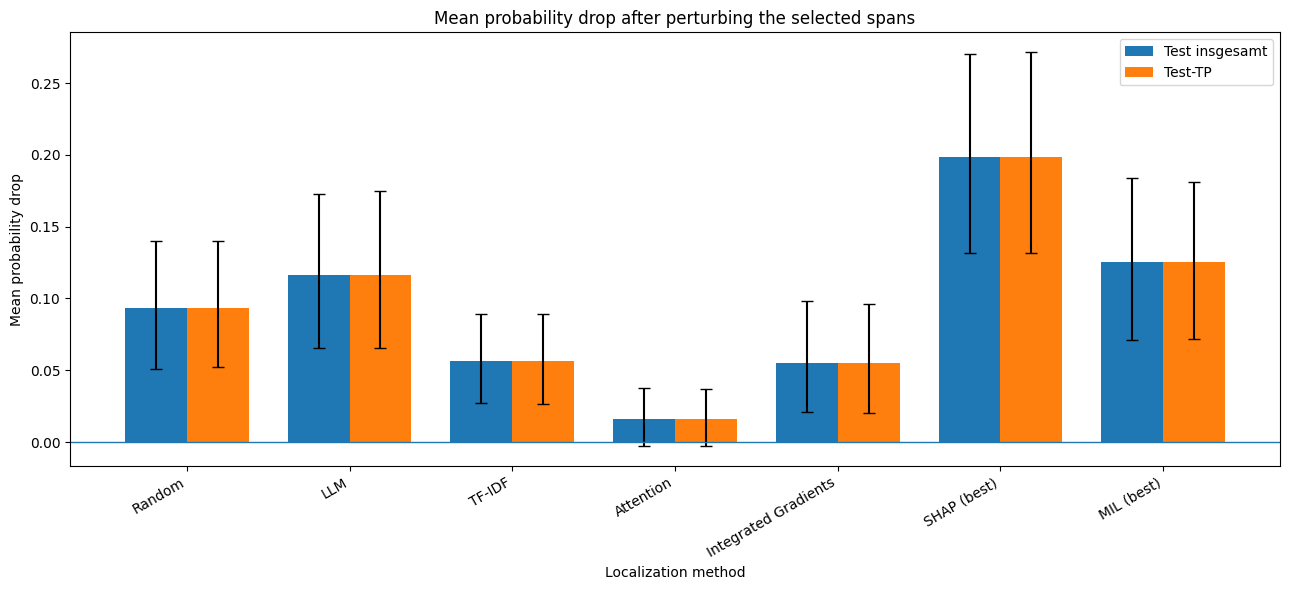

Saved to: results/evaluation/plots/mean_prob_drop_test_vs_tp.png


In [13]:
fig, ax = plt.subplots(
    figsize=(13, 6)
)

x_positions = np.arange(
    len(METHOD_ORDER)
)

subset_names = list(subset_data.keys())
bar_width = 0.38


for subset_index, subset_name in enumerate(
    subset_names
):
    current = (
        bootstrap_summary
        .loc[
            bootstrap_summary["subset"].eq(
                subset_name
            )
        ]
        .set_index("method")
        .reindex(METHOD_ORDER)
    )

    offset = (
        subset_index
        - (len(subset_names) - 1) / 2
    ) * bar_width

    means = current[
        "mean_prob_drop"
    ].to_numpy()

    lower_errors = (
        current["mean_prob_drop"]
        - current["ci_lower"]
    ).to_numpy()

    upper_errors = (
        current["ci_upper"]
        - current["mean_prob_drop"]
    ).to_numpy()

    y_errors = np.vstack([
        lower_errors,
        upper_errors,
    ])

    ax.bar(
        x_positions + offset,
        means,
        width=bar_width,
        yerr=y_errors,
        capsize=4,
        label=subset_name,
    )


ax.axhline(
    0,
    linewidth=1,
)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    [
        method_label(method)
        for method in METHOD_ORDER
    ],
    rotation=30,
    ha="right",
)

ax.set_ylabel(
    "Mean probability drop"
)

ax.set_xlabel(
    "Localization method"
)

ax.set_title(
    "Mean probability drop after perturbing "
    "the selected spans"
)

ax.legend()

fig.tight_layout()

plot_path = (
    PLOT_DIR
    / "mean_prob_drop_test_vs_tp.png"
)

fig.savefig(
    plot_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {plot_path}")

/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_36081/547257956.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


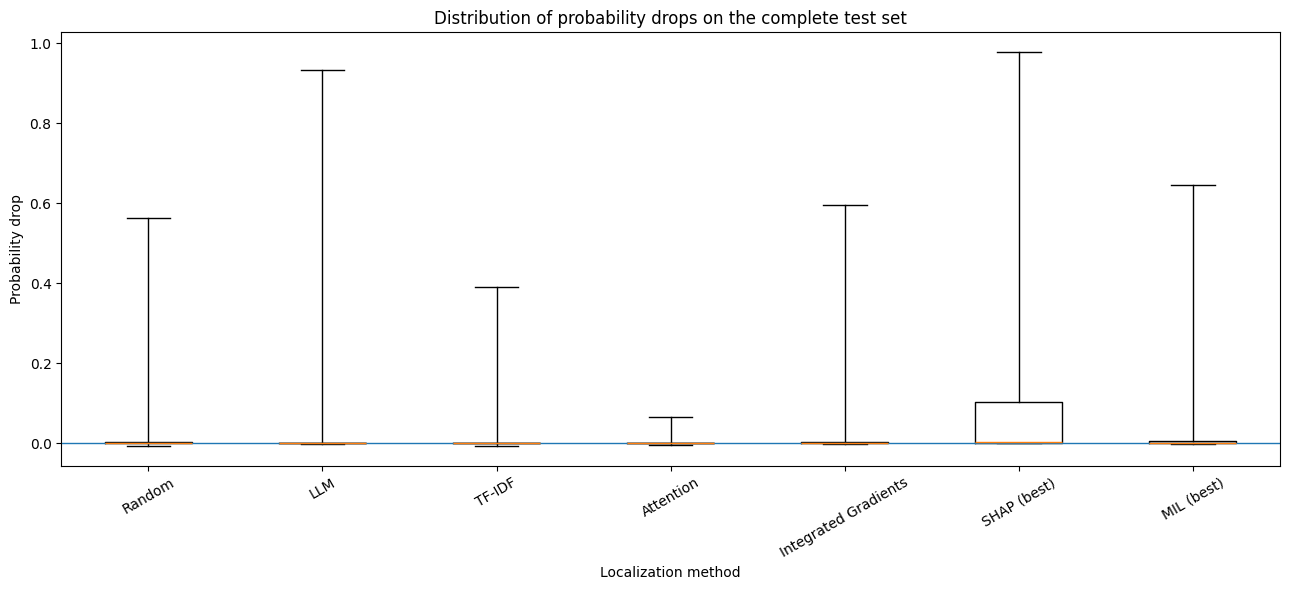

Saved to: results/evaluation/plots/prob_drop_boxplot_test.png


/var/folders/9c/mdcbw50d74b4v7yjj79xw8yh0000gn/T/ipykernel_36081/547257956.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


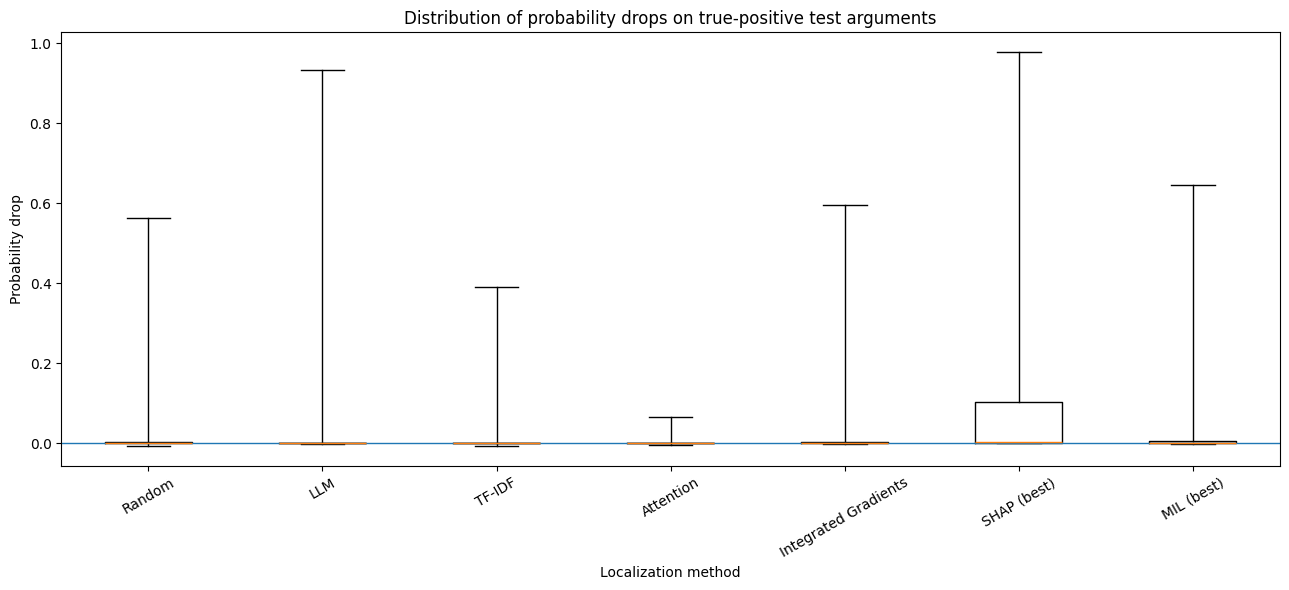

Saved to: results/evaluation/plots/prob_drop_boxplot_test_tp.png


In [14]:
def plot_prob_drop_boxplot(
    df: pd.DataFrame,
    *,
    title: str,
    filename: str,
) -> None:
    """Plot probability-drop distributions by method."""
    values = []
    labels = []

    for method in METHOD_ORDER:
        method_values = (
            df.loc[
                df["method"].eq(method),
                "prob_drop",
            ]
            .dropna()
            .to_numpy()
        )

        if len(method_values) == 0:
            continue

        values.append(method_values)
        labels.append(method_label(method))

    fig, ax = plt.subplots(
        figsize=(13, 6)
    )

    ax.boxplot(
        values,
        labels=labels,
        showfliers=False,
        whis=(5, 95),
    )

    ax.axhline(
        0,
        linewidth=1,
    )

    ax.set_ylabel(
        "Probability drop"
    )

    ax.set_xlabel(
        "Localization method"
    )

    ax.set_title(title)

    ax.tick_params(
        axis="x",
        rotation=30,
    )

    fig.tight_layout()

    output_path = PLOT_DIR / filename

    fig.savefig(
        output_path,
        bbox_inches="tight",
    )

    plt.show()

    print(f"Saved to: {output_path}")


plot_prob_drop_boxplot(
    test_common,
    title=(
        "Distribution of probability drops "
        "on the complete test set"
    ),
    filename="prob_drop_boxplot_test.png",
)

plot_prob_drop_boxplot(
    test_tp,
    title=(
        "Distribution of probability drops "
        "on true-positive test arguments"
    ),
    filename="prob_drop_boxplot_test_tp.png",
)

In [15]:
tp_detailed_table = (
    summary_tp[
        [
            "method",
            "method_label",
            "n_arguments",
            "mean_prob_drop",
            "median_prob_drop",
            "std_prob_drop",
            "q25_prob_drop",
            "q75_prob_drop",
            "positive_drop_rate",
            "strong_drop_rate_001",
            "strong_drop_rate_005",
            "flip_rate_predicted_positive",
            "mean_relative_prob_drop",
            "mean_masked_token_ratio",
            "mean_selected_word_ratio",
            "mean_total_masked_tokens",
            "mean_n_merged_spans",
        ]
    ]
    .copy()
)


display(
    tp_detailed_table[
        [
            "method_label",
            "n_arguments",
            "mean_prob_drop",
            "median_prob_drop",
            "positive_drop_rate",
            "strong_drop_rate_005",
            "flip_rate_predicted_positive",
            "mean_masked_token_ratio",
            "mean_n_merged_spans",
        ]
    ]
    .style
    .format({
        "mean_prob_drop": "{:.4f}",
        "median_prob_drop": "{:.4f}",
        "positive_drop_rate": "{:.1%}",
        "strong_drop_rate_005": "{:.1%}",
        "flip_rate_predicted_positive": "{:.1%}",
        "mean_masked_token_ratio": "{:.1%}",
        "mean_n_merged_spans": "{:.2f}",
    })
)


tp_detailed_table.to_csv(
    TABLE_DIR
    / "detailed_metrics_test_tp.csv",
    index=False,
)

,method_label,n_arguments,mean_prob_drop,median_prob_drop,positive_drop_rate,strong_drop_rate_005,flip_rate_predicted_positive,mean_masked_token_ratio,mean_n_merged_spans
0,Random,100,0.0934,0.0008,81.0%,19.0%,18.0%,48.4%,13.35
1,LLM,100,0.1160,0.0002,69.0%,17.0%,16.0%,27.2%,nan
2,TF-IDF,100,0.0564,0.0003,63.0%,16.0%,5.0%,61.2%,3.80
3,Attention,100,0.0159,0.0007,82.0%,8.0%,2.0%,54.5%,5.36
4,Integrated Gradients,100,0.0554,0.0013,87.0%,10.0%,7.0%,49.9%,9.78
5,SHAP (best),100,0.1988,0.0027,92.0%,27.0%,20.0%,42.0%,7.70
6,MIL (best),100,0.1254,0.0001,63.0%,20.0%,18.0%,53.9%,nan


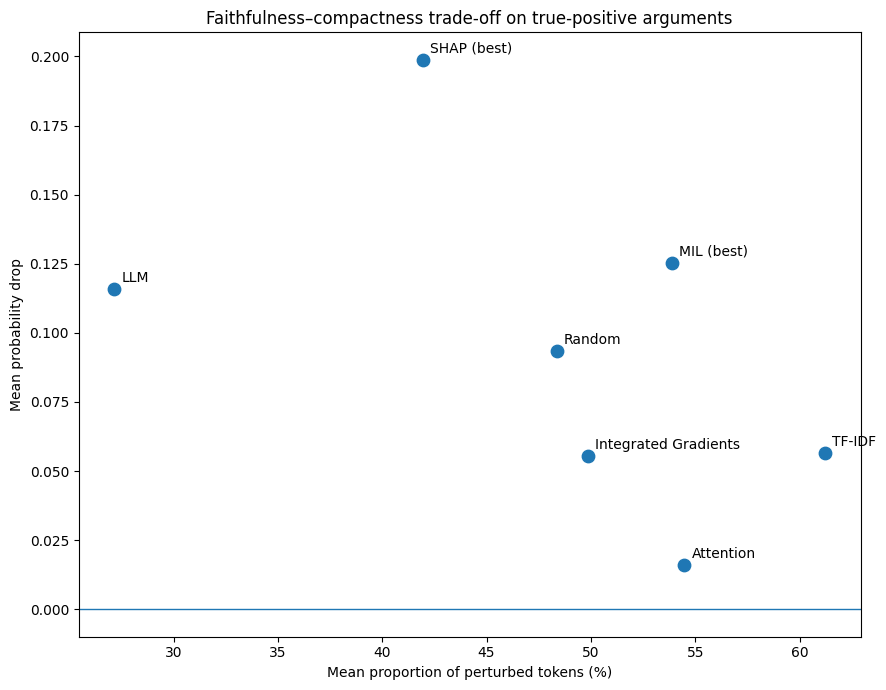

Saved to: results/evaluation/plots/faithfulness_compactness_test_tp.png


In [16]:
compactness_plot_df = (
    summary_tp[
        [
            "method",
            "method_label",
            "mean_prob_drop",
            "mean_masked_token_ratio",
        ]
    ]
    .dropna(
        subset=[
            "mean_prob_drop",
            "mean_masked_token_ratio",
        ]
    )
    .copy()
)

compactness_plot_df[
    "mean_masked_token_percentage"
] = (
    compactness_plot_df[
        "mean_masked_token_ratio"
    ]
    * 100
)


fig, ax = plt.subplots(
    figsize=(9, 7)
)

ax.scatter(
    compactness_plot_df[
        "mean_masked_token_percentage"
    ],
    compactness_plot_df[
        "mean_prob_drop"
    ],
    s=80,
)


for row in compactness_plot_df.itertuples():
    ax.annotate(
        row.method_label,
        (
            row.mean_masked_token_percentage,
            row.mean_prob_drop,
        ),
        xytext=(5, 5),
        textcoords="offset points",
    )


ax.axhline(
    0,
    linewidth=1,
)

ax.set_xlabel(
    "Mean proportion of perturbed tokens (%)"
)

ax.set_ylabel(
    "Mean probability drop"
)

ax.set_title(
    "Faithfulness–compactness trade-off "
    "on true-positive arguments"
)

fig.tight_layout()

plot_path = (
    PLOT_DIR
    / "faithfulness_compactness_test_tp.png"
)

fig.savefig(
    plot_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {plot_path}")

In [17]:
from scipy.stats import wilcoxon, rankdata


def bootstrap_mean_difference_ci(
    differences,
    *,
    n_bootstrap: int = 5000,
    confidence: float = 0.95,
    seed: int = 42,
) -> tuple[float, float, float]:
    """Bootstrap CI for paired mean differences."""
    differences = np.asarray(
        differences,
        dtype=float,
    )

    differences = differences[
        np.isfinite(differences)
    ]

    if len(differences) == 0:
        return np.nan, np.nan, np.nan

    observed_mean = differences.mean()

    if len(differences) == 1:
        return (
            observed_mean,
            observed_mean,
            observed_mean,
        )

    rng = np.random.default_rng(seed)

    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=float,
    )

    for i in range(n_bootstrap):
        bootstrap_sample = rng.choice(
            differences,
            size=len(differences),
            replace=True,
        )

        bootstrap_means[i] = (
            bootstrap_sample.mean()
        )

    alpha = 1 - confidence

    return (
        observed_mean,
        np.quantile(
            bootstrap_means,
            alpha / 2,
        ),
        np.quantile(
            bootstrap_means,
            1 - alpha / 2,
        ),
    )


def rank_biserial_from_paired_differences(
    differences,
) -> float:
    """
    Rank-biserial effect size for paired differences.

    Positive values mean that the evaluated method
    tends to outperform the baseline.
    """
    differences = np.asarray(
        differences,
        dtype=float,
    )

    differences = differences[
        np.isfinite(differences)
    ]

    nonzero = differences[
        differences != 0
    ]

    if len(nonzero) == 0:
        return 0.0

    ranks = rankdata(
        np.abs(nonzero)
    )

    positive_rank_sum = ranks[
        nonzero > 0
    ].sum()

    negative_rank_sum = ranks[
        nonzero < 0
    ].sum()

    return (
        positive_rank_sum
        - negative_rank_sum
    ) / ranks.sum()


def holm_adjust(
    p_values,
) -> np.ndarray:
    """Holm correction without requiring statsmodels."""
    p_values = np.asarray(
        p_values,
        dtype=float,
    )

    n_tests = len(p_values)

    order = np.argsort(p_values)
    adjusted = np.empty(
        n_tests,
        dtype=float,
    )

    previous_adjusted = 0.0

    for rank, original_index in enumerate(order):
        multiplier = n_tests - rank

        current_adjusted = min(
            1.0,
            multiplier
            * p_values[original_index],
        )

        current_adjusted = max(
            previous_adjusted,
            current_adjusted,
        )

        adjusted[original_index] = (
            current_adjusted
        )

        previous_adjusted = (
            current_adjusted
        )

    return adjusted


BASELINE_METHOD = "random_mask"


paired_tp_prob_drop = test_tp.pivot(
    index="global_row_id",
    columns="method",
    values="prob_drop",
)

comparison_rows = []

for method_index, method in enumerate(METHOD_ORDER):
    if method == BASELINE_METHOD:
        continue

    paired_values = (
        paired_tp_prob_drop[
            [method, BASELINE_METHOD]
        ]
        .dropna()
    )

    differences = (
        paired_values[method]
        - paired_values[BASELINE_METHOD]
    ).to_numpy()

    (
        mean_difference,
        ci_lower,
        ci_upper,
    ) = bootstrap_mean_difference_ci(
        differences,
        n_bootstrap=5000,
        confidence=0.95,
        seed=100 + method_index,
    )

    if np.allclose(
        differences,
        0,
    ):
        wilcoxon_statistic = 0.0
        p_value = 1.0
    else:
        test_result = wilcoxon(
            differences,
            zero_method="wilcox",
            alternative="two-sided",
        )

        wilcoxon_statistic = (
            test_result.statistic
        )
        p_value = test_result.pvalue

    comparison_rows.append({
        "method": method,
        "method_label": method_label(method),
        "baseline": BASELINE_METHOD,
        "n_paired_arguments": len(differences),

        "mean_difference_vs_random": (
            mean_difference
        ),
        "median_difference_vs_random": (
            np.median(differences)
        ),

        "ci_lower": ci_lower,
        "ci_upper": ci_upper,

        "win_rate_vs_random": (
            differences > 0
        ).mean(),

        "tie_rate_vs_random": (
            differences == 0
        ).mean(),

        "loss_rate_vs_random": (
            differences < 0
        ).mean(),

        "rank_biserial_effect": (
            rank_biserial_from_paired_differences(
                differences
            )
        ),

        "wilcoxon_statistic": (
            wilcoxon_statistic
        ),
        "p_value": p_value,
    })


random_comparison = pd.DataFrame(
    comparison_rows
)

random_comparison[
    "p_value_holm"
] = holm_adjust(
    random_comparison["p_value"]
)

random_comparison[
    "significant_holm_005"
] = (
    random_comparison["p_value_holm"] < 0.05
)


display(
    random_comparison[
        [
            "method_label",
            "n_paired_arguments",
            "mean_difference_vs_random",
            "ci_lower",
            "ci_upper",
            "win_rate_vs_random",
            "rank_biserial_effect",
            "p_value_holm",
            "significant_holm_005",
        ]
    ]
    .style
    .format({
        "mean_difference_vs_random": "{:.4f}",
        "ci_lower": "{:.4f}",
        "ci_upper": "{:.4f}",
        "win_rate_vs_random": "{:.1%}",
        "rank_biserial_effect": "{:.3f}",
        "p_value_holm": "{:.4g}",
    })
)


random_comparison.to_csv(
    TABLE_DIR
    / "paired_comparison_against_random_test_tp.csv",
    index=False,
)

,method_label,n_paired_arguments,mean_difference_vs_random,ci_lower,ci_upper,win_rate_vs_random,rank_biserial_effect,p_value_holm,significant_holm_005
0,LLM,100,0.0227,-0.0413,0.0916,28.0%,-0.294,0.05314,False
1,TF-IDF,100,-0.0370,-0.0655,-0.0112,25.0%,-0.576,5.842e-06,True
2,Attention,100,-0.0775,-0.1196,-0.0347,43.0%,-0.211,0.2038,False
3,Integrated Gradients,100,-0.0380,-0.0996,0.0267,51.0%,-0.005,0.9671,False
4,SHAP (best),100,0.1054,0.0176,0.1946,57.0%,0.257,0.1035,False
5,MIL (best),100,0.0320,-0.0164,0.0863,34.0%,-0.110,0.6817,False


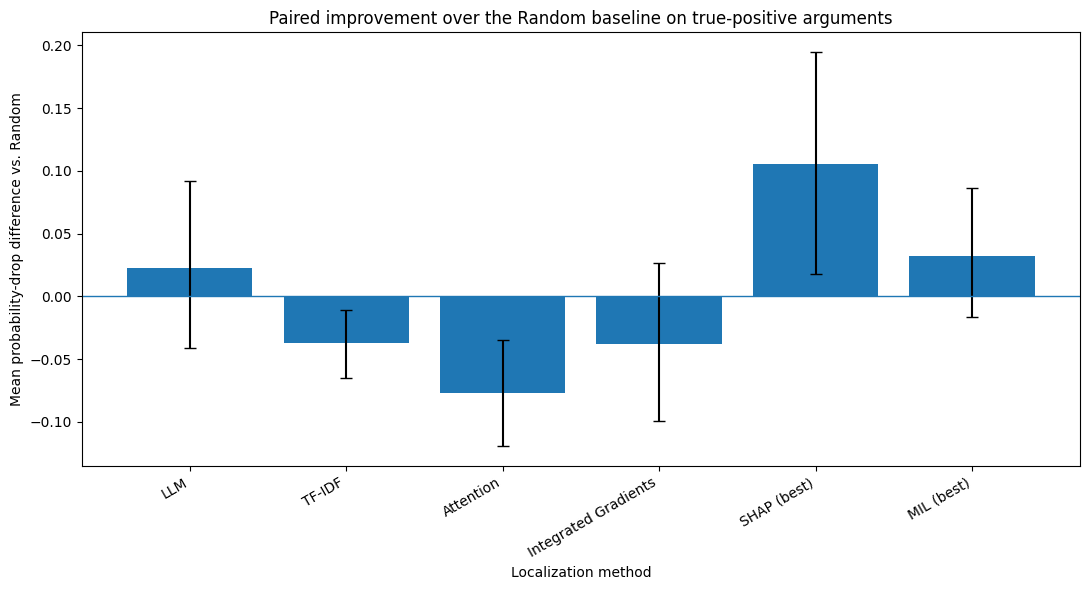

Saved to: results/evaluation/plots/prob_drop_improvement_over_random_test_tp.png


In [18]:
plot_random_comparison = (
    random_comparison
    .set_index("method")
    .reindex([
        method
        for method in METHOD_ORDER
        if method != BASELINE_METHOD
    ])
    .reset_index()
)


fig, ax = plt.subplots(
    figsize=(11, 6)
)

x_positions = np.arange(
    len(plot_random_comparison)
)

means = plot_random_comparison[
    "mean_difference_vs_random"
].to_numpy()

lower_errors = (
    plot_random_comparison[
        "mean_difference_vs_random"
    ]
    - plot_random_comparison["ci_lower"]
).to_numpy()

upper_errors = (
    plot_random_comparison["ci_upper"]
    - plot_random_comparison[
        "mean_difference_vs_random"
    ]
).to_numpy()


ax.bar(
    x_positions,
    means,
    yerr=np.vstack([
        lower_errors,
        upper_errors,
    ]),
    capsize=4,
)

ax.axhline(
    0,
    linewidth=1,
)

ax.set_xticks(x_positions)

ax.set_xticklabels(
    plot_random_comparison[
        "method_label"
    ],
    rotation=30,
    ha="right",
)

ax.set_ylabel(
    "Mean probability-drop difference vs. Random"
)

ax.set_xlabel(
    "Localization method"
)

ax.set_title(
    "Paired improvement over the Random baseline "
    "on true-positive arguments"
)

fig.tight_layout()

plot_path = (
    PLOT_DIR
    / "prob_drop_improvement_over_random_test_tp.png"
)

fig.savefig(
    plot_path,
    bbox_inches="tight",
)

plt.show()

print(f"Saved to: {plot_path}")